# Training MobileNetV2 — Klasifikasi 10 Makanan Indonesia

Baseline classifier untuk CV pipeline (`cv-baseline-v0.1`).

**Struktur data yang diharapkan:**
```
DATA_ROOT/
├── train/
│   ├── bakso/ bebek_betutu/ gado_gado/ gudeg/ nasi_goreng/
│   └── pempek/ rawon/ rendang/ sate/ soto/
└── test/
    └── (10 folder yang sama)
```

**Catatan:**
- `val` di-split otomatis dari `train/` (default 20%).
- `test/` hanya dipakai untuk evaluasi akhir, tidak untuk memilih checkpoint.
- Semua hyperparameter ada di cell **CONFIG** di bawah. Ubah di situ saja.
- Pastikan Kaggle **Accelerator = GPU** sudah aktif (Settings di panel kanan).

## 1. Setup & CONFIG

In [1]:
import os, json, random, datetime
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# ============ CONFIG — ubah di sini saja ============
CONFIG = {
    # ganti sesuai slug dataset Kaggle kamu
    "DATA_ROOT":   "/kaggle/input/datasets/iwayansatya/food-datasett",
    "OUTPUT_DIR":  "/kaggle/working",

    "IMAGE_SIZE":  224,
    "BATCH_SIZE":  32,
    "VAL_SPLIT":   0.2,
    "SEED":        42,

    "EPOCHS":      10,
    "LR":          1e-4,
    "FREEZE_BACKBONE": False,   # True = latih head saja (lebih cepat, akurasi lebih rendah)

    "NUM_WORKERS": 2,
    "MODEL_NAME":  "mobilenetv2_food10",
}
# ====================================================

random.seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])
torch.manual_seed(CONFIG["SEED"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("PERINGATAN: GPU tidak terdeteksi. Aktifkan Accelerator > GPU di setting Kaggle.")

Device: cuda


## 2. Transforms & Data Loading

In [2]:
IMG = CONFIG["IMAGE_SIZE"]
# normalisasi ImageNet (backbone-nya pretrained ImageNet)
NORM = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    NORM,
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG * 1.14)),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    NORM,
])

train_dir = os.path.join(CONFIG["DATA_ROOT"], "train")
test_dir  = os.path.join(CONFIG["DATA_ROOT"], "test")

full_train = datasets.ImageFolder(train_dir, transform=train_tf)
test_ds    = datasets.ImageFolder(test_dir,  transform=eval_tf)

CLASS_TO_IDX = full_train.class_to_idx
CLASSES      = full_train.classes
NUM_CLASSES  = len(CLASSES)

# split train/val
n_val   = int(len(full_train) * CONFIG["VAL_SPLIT"])
n_train = len(full_train) - n_val
g = torch.Generator().manual_seed(CONFIG["SEED"])
train_ds, val_ds = random_split(full_train, [n_train, n_val], generator=g)

# val tidak boleh pakai augmentasi -> pakai copy dataset dengan eval_tf
val_base = datasets.ImageFolder(train_dir, transform=eval_tf)
val_ds.dataset = val_base

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=shuffle,
                      num_workers=CONFIG["NUM_WORKERS"], pin_memory=True)

train_loader = make_loader(train_ds, True)
val_loader   = make_loader(val_ds,   False)
test_loader  = make_loader(test_ds,  False)

print(f"Kelas ({NUM_CLASSES}): {CLASSES}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# cek distribusi per kelas (penting: kelas dengan data sedikit rawan akurasi rendah)
from collections import Counter
dist = Counter([full_train.targets[i] for i in train_ds.indices])
for c in CLASSES:
    print(f"  {c:<15} {dist[CLASS_TO_IDX[c]]}")

Kelas (10): ['bakso', 'bebek_betutu', 'gado_gado', 'gudeg', 'nasi_goreng', 'pempek', 'rawon', 'rendang', 'sate', 'soto']
Train: 2293 | Val: 573 | Test: 1193
  bakso           261
  bebek_betutu    186
  gado_gado       207
  gudeg           173
  nasi_goreng     293
  pempek          222
  rawon           195
  rendang         189
  sate            284
  soto            283


## 3. Model — MobileNetV2

In [3]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

if CONFIG["FREEZE_BACKBONE"]:
    for p in model.features.parameters():
        p.requires_grad = False

# ganti classifier head -> 10 kelas
in_feat = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feat, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["LR"]
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s]


Trainable params: 2,236,682


## 4. Training Loop

In [4]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train_mode):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            loss = criterion(out, y)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / total, correct / total


best_val_acc = 0.0
best_state   = None
history      = []

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader,  False)
    history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                    "val_loss": va_loss, "val_acc": va_acc})

    tag = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        tag = "  <- best"

    print(f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}{tag}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")
model.load_state_dict(best_state)  # pakai checkpoint terbaik, bukan epoch terakhir

Epoch 01/10 | train loss 1.3570 acc 0.5853 | val loss 0.7407 acc 0.7906  <- best
Epoch 02/10 | train loss 0.5526 acc 0.8513 | val loss 0.5360 acc 0.8290  <- best
Epoch 03/10 | train loss 0.3440 acc 0.9019 | val loss 0.4948 acc 0.8499  <- best
Epoch 04/10 | train loss 0.2266 acc 0.9424 | val loss 0.4720 acc 0.8674  <- best
Epoch 05/10 | train loss 0.1540 acc 0.9603 | val loss 0.4776 acc 0.8499
Epoch 06/10 | train loss 0.1150 acc 0.9695 | val loss 0.4758 acc 0.8621
Epoch 07/10 | train loss 0.0893 acc 0.9756 | val loss 0.5150 acc 0.8551
Epoch 08/10 | train loss 0.0801 acc 0.9830 | val loss 0.5522 acc 0.8342
Epoch 09/10 | train loss 0.0542 acc 0.9887 | val loss 0.4821 acc 0.8551
Epoch 10/10 | train loss 0.0451 acc 0.9922 | val loss 0.4968 acc 0.8621

Best val accuracy: 0.8674


<All keys matched successfully>

## 5. Evaluasi di Test Set

Test accuracy: 0.8659

              precision    recall  f1-score   support

       bakso      0.917     0.854     0.884       130
bebek_betutu      0.767     0.814     0.790        97
   gado_gado      0.853     0.823     0.838       113
       gudeg      0.780     0.780     0.780        82
 nasi_goreng      0.952     0.903     0.927       155
      pempek      0.852     0.935     0.891       123
       rawon      0.852     0.885     0.868       104
     rendang      0.872     0.798     0.833        94
        sate      0.940     0.909     0.924       154
        soto      0.810     0.879     0.844       141

    accuracy                          0.866      1193
   macro avg      0.860     0.858     0.858      1193
weighted avg      0.868     0.866     0.866      1193



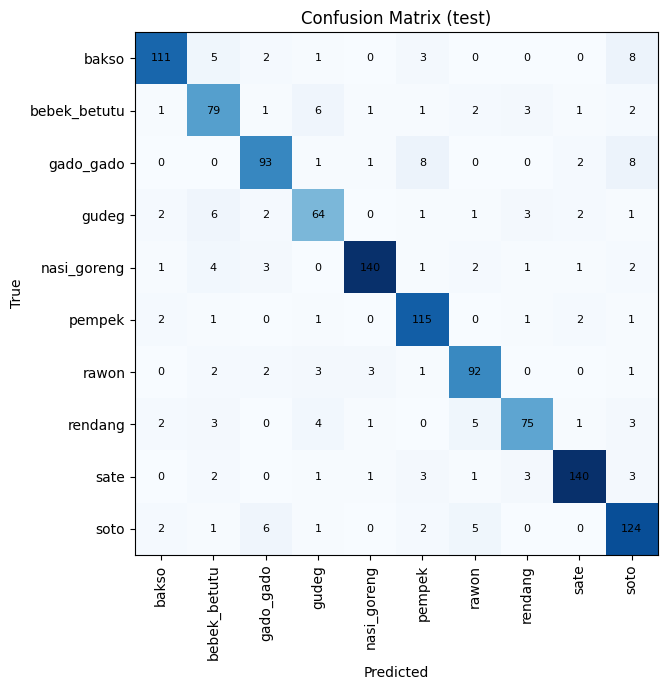

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(DEVICE))
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(y.numpy())

test_acc = float(np.mean(np.array(y_true) == np.array(y_pred)))
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=90)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix (test)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 6. Export Model (.pt) + Metadata

In [6]:
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
name = CONFIG["MODEL_NAME"]

pt_path   = os.path.join(CONFIG["OUTPUT_DIR"], f"{name}.pt")
cls_path  = os.path.join(CONFIG["OUTPUT_DIR"], "class_to_idx.json")
meta_path = os.path.join(CONFIG["OUTPUT_DIR"], "training_metadata.json")

# simpan state_dict + class mapping dalam satu file (aman saat load ulang)
torch.save({
    "model_state_dict": model.state_dict(),
    "arch": "mobilenet_v2",
    "num_classes": NUM_CLASSES,
    "class_to_idx": CLASS_TO_IDX,
    "image_size": IMG,
}, pt_path)

with open(cls_path, "w") as f:
    json.dump(CLASS_TO_IDX, f, indent=2)

meta = {
    "model_version": "cv-baseline-v0.1",
    "arch": "mobilenet_v2 (pretrained ImageNet)",
    "classes": CLASSES,
    "n_train": len(train_ds), "n_val": len(val_ds), "n_test": len(test_ds),
    "best_val_acc": best_val_acc,
    "test_acc": test_acc,
    "config": CONFIG,
    "history": history,
    "trained_at": datetime.datetime.now().isoformat(),
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("Tersimpan:")
for p in [pt_path, cls_path, meta_path]:
    print(f"  {p}  ({os.path.getsize(p)/1e6:.2f} MB)")

Tersimpan:
  /kaggle/working/mobilenetv2_food10.pt  (9.20 MB)
  /kaggle/working/class_to_idx.json  (0.00 MB)
  /kaggle/working/training_metadata.json  (0.00 MB)


## 7. Sanity Check — Load Ulang Model

Verifikasi file `.pt` bisa dipakai ulang di luar notebook ini (nanti untuk mengisi `TorchvisionClassifier` di pipeline `predict()`).

In [7]:
ckpt = torch.load(pt_path, map_location="cpu")

m = models.mobilenet_v2(weights=None)
m.classifier[1] = nn.Linear(m.classifier[1].in_features, ckpt["num_classes"])
m.load_state_dict(ckpt["model_state_dict"])
m.eval()

idx_to_class = {v: k for k, v in ckpt["class_to_idx"].items()}

# prediksi 1 gambar dari test set
img, label = test_ds[0]
with torch.no_grad():
    probs = torch.softmax(m(img.unsqueeze(0)), dim=1)[0]

top3 = torch.topk(probs, 3)
print("Ground truth :", idx_to_class[label])
print("Top-3 prediksi:")
for p, i in zip(top3.values, top3.indices):
    print(f"  {idx_to_class[int(i)]:<15} {float(p):.4f}")

Ground truth : bakso
Top-3 prediksi:
  bakso           0.7032
  pempek          0.2205
  soto            0.0471


---
## Keterbatasan yang perlu dicatat

1. **Akurasi bergantung jumlah data per kelas.** Cek output distribusi di section 2 — kelas dengan gambar sedikit akan punya recall rendah di classification report.
2. **Kelas mirip secara visual** (rawon vs rendang, keduanya gelap kecoklatan; soto vs bakso, keduanya berkuah) berpotensi tertukar. Lihat confusion matrix untuk konfirmasi.
3. **Model ini hanya klasifikasi kategori**, bukan estimasi porsi. Nilai makro tetap berasal dari lookup TKPI, jadi error porsi belum tertangani.
4. **Mapping TKPI low-confidence** untuk `sate` dan `bebek_betutu` masih berlaku — tidak terpengaruh training ini, tapi tetap membatasi akurasi makro akhirnya.
5. Setelah `.pt` ini diintegrasikan, `feature_status` baru boleh berubah dari `stub_untrained` ke `ok`.